## Read in data

In [45]:
import pandas as pd

In [ ]:
# i made each data set have its own .csv file and dataframe

df_2_35 = pd.read_csv('hw_2_threshold_2_35.csv')
df_2_4 = pd.read_csv('hw_2_threshold_2_4.csv')
df_2_45 = pd.read_csv('hw_2_threshold_2_45.csv')
df_2_5 = pd.read_csv('hw_2_threshold_2_5.csv')
df_2_6 = pd.read_csv('hw_2_threshold_2_6.csv')

## Make overlays of the poisson and gaussian distributions on my data


In [3]:
def make_overlays(title, df, nbins, nlo, nhi):
  ''' Prepare histograms and make overlays of poissons and gaussians whose
  parameters match the means and stdev's of the data.

  Parameters
  ----------
  title : string
    A name for this run of the experiment
  df : panda DataFrame
    The data from this run of the experiment
  nbins : int
    How maby bins to use for histogram
  nlo : float
    Low edge of histogram
  nhi : float
    High edge of histogram
  '''
  import numpy as np
  import matplotlib.pyplot as plt
  #
  # Make a histrogram of our results for the counts from the
  # various trials. We will plot this with sqrt(n) error bars on the
  # histogram bin contents.
  #
  n      = df['n']
  mean   = n.mean()
  stddev = n.std()
  ntrial = len(n)
  counts, bins = np.histogram(n, bins=np.linspace(nlo, nhi, nbins+1))
  sigma_counts = np.sqrt(counts)
  bin_centers  = 0.5*(bins[1:]+bins[:-1])
  plt.hist(bins[:-1], bins, weights=counts, color='lightblue')
  plt.errorbar(bin_centers, counts, yerr=sigma_counts, fmt='o', color='black', ecolor='black')
  #
  # Now plot the expected distribution for poisson distributed data
  # of the same mean as our data trials
  #
  import scipy.stats as stats
  #
  # We'll compute out to nhi rounded up to an integer
  #
  nx = int(nhi+1)
  x  = np.linspace(0,nx,nx+1)
  #
  # The normalization of the expected curve is a little tricky. Since the
  # poisson PDF is "per trial per count" we have to:
  #  - mulitply up by the number of trials we ran (len(df['n']))
  #  - multiply up by the width of the bins ((nhi-nlo)/nbins)
  # The formula for a poisson distribution is f(n) = exp(-mu)*mu^n/n!
  # As it happens this PDF is coded into scipy as poisson.pmf(...)
  # Same logic applies to the guassian ("normal") distribution.
  #
  norm = ntrial*(nhi-nlo)/nbins
  yp   = norm*stats.poisson.pmf(x, mean)
  yg   = norm*stats.norm.pdf(x,loc=mean,scale=stddev)
  plt.plot(x,yp,color='r',label='poisson')
  plt.plot(x,yg,color='b',label='gaussian')
  #
  # The rest is plot formatting
  #
  plt.xlabel('Counts')
  plt.ylabel('Number of trials / bin')
  plt.xlim([nlo,nhi])
  plt.grid(color='lightgrey')
  plt.legend()
  plt.title('%s : poisson and gaussian overlaid'%title)
  plt.savefig('%s-plot.pdf'%title, format="pdf", bbox_inches="tight")
  plt.show()

## Make fits to the poisson and gaussian distributions


To make fits to these distributions we need:

1. A $\chi^2$ function to compare the data and the model (gaussian or poisson)

2. Functions which return the Poisson or Gaussian predictions,
\begin{equation}
C(x) = A \frac{\mu^x e^{-x}}{x!} ~~~~~~~ [Poisson],
\end{equation}
\begin{equation}
C(x) = A \exp\left( {-\frac{(x-\mu)^2}{2 \sigma^2}} \right) ~~~~~~~[Gaussian]
\end{equation}
for the number of occurances $C$ as a function of the number of counts $x$ given a mean expectation of $\mu$, and a width of $\sigma$. NOTE: The Poisson formula depends onlly on A and $\mu$, the standard deviation and mean are coupled through the equation $\sigma = \sqrt{\mu}$. For both formulae, $A$ is a normalization constant proportional to the number of trials taken.

3. A way to find the model parameters ($A$, $\mu$, $\sigma$) that best-fit out data, minimizing $\chi^2$.

4. A way to estimate the uncertainties once the fit is complete. These are calculated based on the curvature of the $\chi^2$ at the minimum and calculating the excursion $\sigma_p$ required to increase the $\chi^2$ by one unit.

For example, the error on the parameter $\mu$ is estimated according to:
\begin{equation}
\chi^2 \simeq \chi^2_0 +
\frac{1}{2} \frac{ \partial^2 \chi^2 } {\partial \mu^2}
\sigma_\mu^2
\end{equation}
where the linear term in this Taylor series is $0$ by
construction since we are working at the $\chi^2$ minimum. Then:
\begin{equation}
\sigma_\mu =  \left( \frac{2}{\frac{ \partial^2 \chi^2 } {\partial \mu^2}} \right)^{\frac{1}{2}}
\end{equation}

In [4]:
import numpy as np
def chisqr(par, args):
  ''' A collection of chisqr functions which compare an observed number of
  counts, Nobs to a predicted number of counts Npred.

  Parameters:
  par : array of floats
    The parameters of the function whichs predicts observations
  args : array of mixed types:
    arg[0] : The model function of form Npred = func(x, par)
    arg[1] : The array of observed data counts Nobs in bins
    arg[2] : Array of x values as center of bins
    arg[3] : string options. Choose: gp, gm or p (see below)

  The functions implement different assumptions about the form of the chi^2.
  Options are:

  'gaussian' : Use the gaussian approximation for the variation in the
  histogram counts: [(Nobs-Npred)/sqrt(Npred)]^2

  'gaussian-o' : Use the gaussian approximation for the variation in the
  histogram counts, based on the observed counts: [(Nobs-Npred)/sqrt(Nobs)]^2

  'poisson' : Use the poisson form of chi^2 based on -2 log (L_poisson)

  See, eg. the Particle Data Group review on statistics:
  https://pdg.lbl.gov/2020/reviews/rpp2020-rev-statistics.pdf eqn. 40.16
  '''
  func  = args[0] # Which model function to call
  Nobs  = args[1] # The data we are comparing to
  xc    = args[2] # x values at center of bins
  opt   = args[3] # How to calculate the chi^2?
  Npred = func(xc, *par)

  if opt=='gaussian':
    delta = Nobs - Npred
    sigma = np.sqrt(Npred)
    chi2 = ((delta/sigma)**2).sum()
  elif opt=='gaussian-o':
    delta = Nobs - Npred
    sigma = np.sqrt(Nobs+1)
    chi2 = ((delta/sigma)**2).sum()
  elif opt=='poisson':
    tiny = 1e-12
    sum1 = Npred.sum()
    sum2 = Nobs.sum()
    sum3 = (Nobs*(np.log((Nobs+tiny)/(Npred+tiny)))).sum()
    chi2 = 2.0*(sum1-sum2+sum3)
  else:
    raise Exception('Please select gaussian, gaussian-o, or poisson')
  return chi2

def test_chisqrs():
  ''' A unit test of the chisqr functions above. As a test, take a linear model
  N = A + x*B with A = 1 and B = 2. Provide some fake data distributed around
  that model and be sure to include a zero bin as that is an important edge
  case the code should handle gracefully.
  '''
  def test_func(x, A, B):
    return A + x*B
  xc   = np.array([1, 2, 3,  4,  5])
  Nobs = np.array([0, 3, 7, 11, 12])
  arg1 = (test_func, Nobs, xc, 'gaussian')
  arg2 = (test_func, Nobs, xc, 'gaussian-o')
  arg3 = (test_func, Nobs, xc, 'poisson')
  par  = [1, 2]
  c1 = chisqr(par, arg1)
  c2 = chisqr(par, arg2)
  c3 = chisqr(par, arg3)
  print(c1, c2, c3)
# test_chisqrs()

In [5]:
import math
import scipy.stats as stats
#
# Our two models: the data is gaussian distributed or poisson distributed.
#
def gaussian_pdf(x, A, x0, sigma):
  return A*stats.norm.pdf(x,loc=x0,scale=sigma)
def poisson_pdf(x, A, mean):
  return A*stats.poisson.pmf(x, mean)

def make_fits(title, df, nbins, nlo, nhi, model_opt, chi2_opt):
  ''' Prepare histograms and make fits to poissons and gaussians
  Parameters
  ----------
  title : string
    A name for this run of the experiment
  df : panda DataFrame
    The data from this run of the experiment
  nbins : int
    How many bins to use for histogram
  nlo : float
    Low edge of histogram
  nhi : float
    High edge of histogram
  model_opt: string
    Which model to use for the data? Gaussian ('g') or poisson ('p')
  chi2_opt : string
    Which form of chi^2 to use? ('gn', 'gp', or 'p'). See chisqr(...)
  '''
  import numpy as np
  import matplotlib.pyplot as plt
  #
  # Make a histrogram of our results for the counts from the
  # various trials. Keep track of the bin center locations, xc.
  #
  Nobs, bins = np.histogram(df['n'], bins=np.linspace(nlo, nhi, nbins+1))
  xc         = np.round(0.5*(bins[1:]+bins[:-1]))
  #
  # Initialize the fit parameters switching between the gaussian model and
  # poisson
  #
  arg   = None
  names = None
  if model_opt=='gaussian':
    names = ['A','mean','sigma']
    x0 = np.array([0,0,0])
    x0[0] = Nobs.max()              # a guess at the normalization
    x0[1] = 0.5*(xc.max()+xc.min()) # a guess at the center
    x0[2] = 0.3*(xc.max()-xc.min()) # a guess at the width
    arg = [gaussian_pdf, Nobs, xc, chi2_opt]
  elif model_opt=='poisson':
    names = ['A','mean']
    x0 = np.array([0,0])
    x0[0] = Nobs.max()              # a guess at the normalization
    x0[1] = 0.5*(xc.max()+xc.min()) # a guess at the mean
    arg = [poisson_pdf,  Nobs, xc, chi2_opt]
  #
  # Run the minimizer. I'm using Nelder-Mead which may not be the fastest
  # minimizer out there, but it is very good at not getting lost.
  #
  from scipy.optimize import minimize
  result = minimize(chisqr, x0, arg, method='Nelder-Mead')
  #
  # Unpack and report results
  #
  chimin = result.fun
  x0     = result.x
  #
  # To compute the errors on x0 we look at the curvature of the chi^2 around
  # the minimum.
  #
  sigma  = np.empty(len(x0))
  x0up   = np.empty(len(x0))
  x0dn   = np.empty(len(x0))
  eps    = 0.1
  for i in range(0,len(x0)):
    x0up[:] = x0
    x0dn[:] = x0
    x0up[i] = x0up[i]+eps
    x0dn[i] = x0dn[i]-eps
    chiup = chisqr(x0up, arg)
    chidn = chisqr(x0dn, arg)
    #
    # Finite difference formula for 2nd derivative
    #
    curv = (chiup + chidn - 2.0*chimin)/eps/eps
    if curv==0.0:
      curv = 1e-9
    sigma[i] = math.sqrt(2.0/math.fabs(curv))
  print('** %s'%title)
  print(' Fit to %s PDF using %s errors on bins'%(model_opt, chi2_opt))
  print(' chi^2 = %f / %d DOF'%(chimin,np.count_nonzero(Nobs)-len(x0)))
  for i in range(len(x0)):
    print(' %s = %f +/- %f'%(names[i],x0[i],sigma[i]))
  return

## Process data

Define one function which runs each of the analysis tasks I want performed. Then step through each of my runs and run the analysis jobs.

In [6]:
#
# Since I'll want to do roughly the same analysis for each run, write that
# analysis once.
#
def proc_run(title, df, nbins, nlo, nhi):
  """ Perform analysis for a single run of the experiment
  Parameters
  ----------
  title : string
    A name for this run of the experiment
  df : panda DataFrame
    The data from this run of the experiment
  nbins : int
    How maby bins to use for histogram
  nlo : float
    Low edge of histogram
  nhi : float
    High edge of histogram
  """
  print('||*** Results for run \'%s\''%title)
  mean   = df['n'].mean()
  stddev = df['n'].std()
  ntrial = len(df['n'])
  print(' Mean    = %f'%mean)
  print(' StdDev  = %f'%stddev)
  print(' Ntrials = %d'%ntrial)
  #
  # Overlay the gaussian and poisson distributions of
  # the same mean and stddev as the data
  #
  make_overlays(title, df, nbins, nlo, nhi)
  #
  # Perform fits to gaussian and poisson letting the
  # normalizations, means, and sigma vary to fit
  # the data.
  #
  # When doing the fits we have two choices to make:
  # -- Which distribution to fit? poisson or gaussian
  # -- What to assume about the distribution of the bin contents?
  #    Are they gaussian or poisson distributed?
  #
  #
  PDF1    = 'poisson'
  PDF2    = 'gaussian'
  BINPDF1 = 'poisson'
  BINPDF2 = 'gaussian'
  make_fits(title, df, nbins, nlo, nhi, PDF1, BINPDF1)
  make_fits(title, df, nbins, nlo, nhi, PDF2, BINPDF1)
  make_fits(title, df, nbins, nlo, nhi, PDF1, BINPDF2)
  make_fits(title, df, nbins, nlo, nhi, PDF2, BINPDF2)

  print('==*** end report for run \'%s\'\n'%title)


## Graphs

||*** Results for run 'Threshold: 2.6'
 Mean    = 1.175000
 StdDev  = 1.058289
 Ntrials = 200


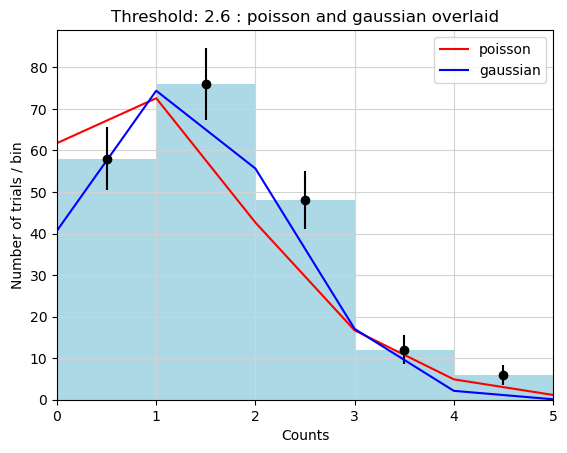

** Threshold: 2.6
 Fit to poisson PDF using poisson errors on bins
 chi^2 = 8.822543 / 3 DOF
 A = 246.795038 +/- 17.451044
 mean = 1.414214 +/- 0.082200
** Threshold: 2.6
 Fit to gaussian PDF using poisson errors on bins
 chi^2 = 8.416226 / 2 DOF
 A = 273.373930 +/- 19.330455
 mean = 1.066804 +/- 0.110476
 sigma = 1.415417 +/- 0.089808
** Threshold: 2.6
 Fit to poisson PDF using gaussian errors on bins
 chi^2 = 8.593449 / 3 DOF
 A = 251.491874 +/- 17.595160
 mean = 1.432615 +/- 0.084382
** Threshold: 2.6
 Fit to gaussian PDF using gaussian errors on bins
 chi^2 = 8.191309 / 2 DOF
 A = 277.170270 +/- 19.401252
 mean = 1.091849 +/- 0.109574
 sigma = 1.416463 +/- 0.088097
==*** end report for run 'Threshold: 2.6'



In [44]:
proc_run('Threshold: 2.6',df_2_6 , 5,   0,   5)

||*** Results for run 'Threshold: 2.5'
 Mean    = 2.690000
 StdDev  = 1.595817
 Ntrials = 200


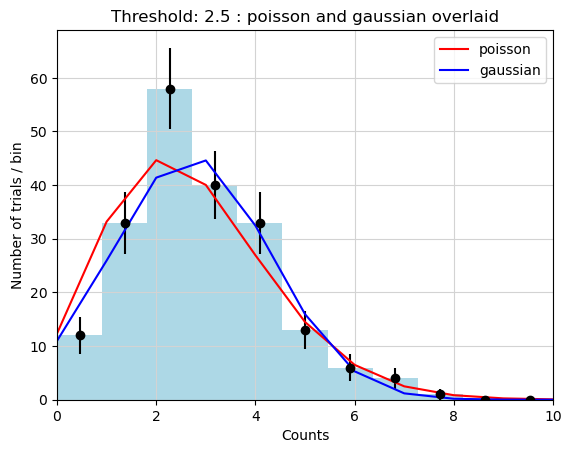

** Threshold: 2.5
 Fit to poisson PDF using poisson errors on bins
 chi^2 = 4.792471 / 7 DOF
 A = 200.023417 +/- 14.143791
 mean = 2.691002 +/- 0.116136
** Threshold: 2.5
 Fit to gaussian PDF using poisson errors on bins
 chi^2 = 9.662253 / 6 DOF
 A = 208.059948 +/- 14.712059
 mean = 2.535659 +/- 0.134394
 sigma = 1.743453 +/- 0.105819
** Threshold: 2.5
 Fit to poisson PDF using gaussian errors on bins
 chi^2 = 4.498657 / 7 DOF
 A = 202.273955 +/- 14.223170
 mean = 2.703981 +/- 0.117946
** Threshold: 2.5
 Fit to gaussian PDF using gaussian errors on bins
 chi^2 = 10.194332 / 6 DOF
 A = 214.490923 +/- 14.977146
 mean = 2.533096 +/- 0.137761
 sigma = 1.798840 +/- 0.090491
==*** end report for run 'Threshold: 2.5'



In [ ]:
proc_run('Threshold: 2.5',df_2_5 , 11,0,1)

||*** Results for run 'Threshold: 2.45'
 Mean    = 45.500000
 StdDev  = 6.828848
 Ntrials = 200


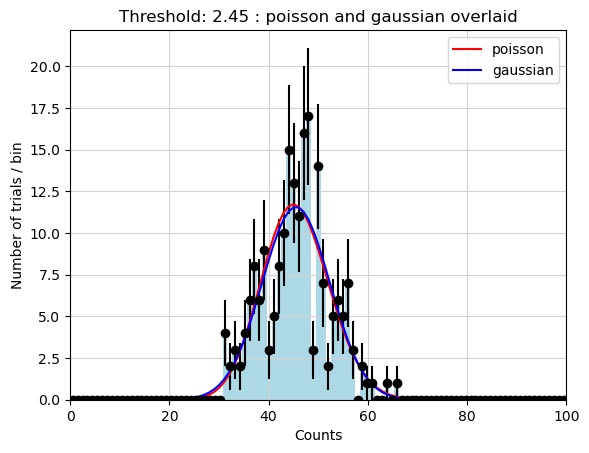

** Threshold: 2.45
 Fit to poisson PDF using poisson errors on bins
 chi^2 = 54.154075 / 30 DOF
 A = 200.000008 +/- 14.142135
 mean = 45.499998 +/- 0.476969
** Threshold: 2.45
 Fit to gaussian PDF using poisson errors on bins
 chi^2 = 54.391537 / 29 DOF
 A = 200.000037 +/- 14.142137
 mean = 45.500000 +/- 0.481664
 sigma = 6.811755 +/- 0.340505
** Threshold: 2.45
 Fit to poisson PDF using gaussian errors on bins
 chi^2 = 48.271809 / 30 DOF
 A = 224.135891 +/- 14.971166
 mean = 45.600549 +/- 0.412504
** Threshold: 2.45
 Fit to gaussian PDF using gaussian errors on bins
 chi^2 = 45.176748 / 29 DOF
 A = 222.588399 +/- 14.919397
 mean = 45.627250 +/- 0.492594
 sigma = 7.349554 +/- 0.340193
==*** end report for run 'Threshold: 2.45'



In [ ]:
proc_run('Threshold: 2.45',df_2_45 , 101,   0,   100)

||*** Results for run 'Threshold: 2.4'
 Mean    = 13.790000
 StdDev  = 3.616809
 Ntrials = 200


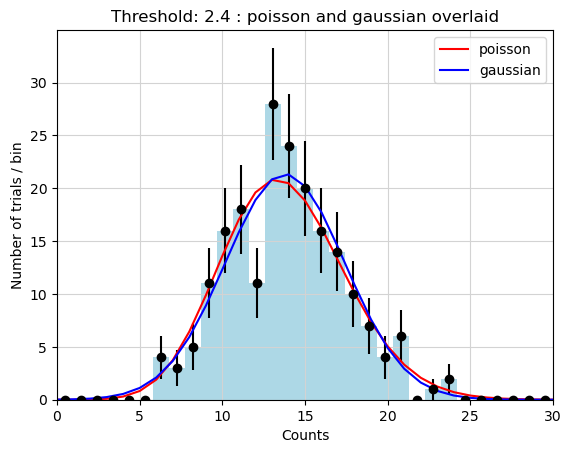

** Threshold: 2.4
 Fit to poisson PDF using poisson errors on bins
 chi^2 = 21.888216 / 16 DOF
 A = 200.009127 +/- 14.142780
 mean = 13.790821 +/- 0.262722
** Threshold: 2.4
 Fit to gaussian PDF using poisson errors on bins
 chi^2 = 23.782217 / 15 DOF
 A = 200.007433 +/- 14.142660
 mean = 13.789488 +/- 0.255269
 sigma = 3.608904 +/- 0.180786
** Threshold: 2.4
 Fit to poisson PDF using gaussian errors on bins
 chi^2 = 17.999105 / 16 DOF
 A = 209.009790 +/- 14.457523
 mean = 13.842875 +/- 0.251220
** Threshold: 2.4
 Fit to gaussian PDF using gaussian errors on bins
 chi^2 = 20.341649 / 15 DOF
 A = 210.192535 +/- 14.498768
 mean = 13.832798 +/- 0.265955
 sigma = 3.853262 +/- 0.183293
==*** end report for run 'Threshold: 2.4'



In [ ]:
proc_run('Threshold: 2.4',df_2_4 , 31,   0,   30)

||*** Results for run 'Threshold: 2.35'
 Mean    = 89.713568
 StdDev  = 9.864402
 Ntrials = 199


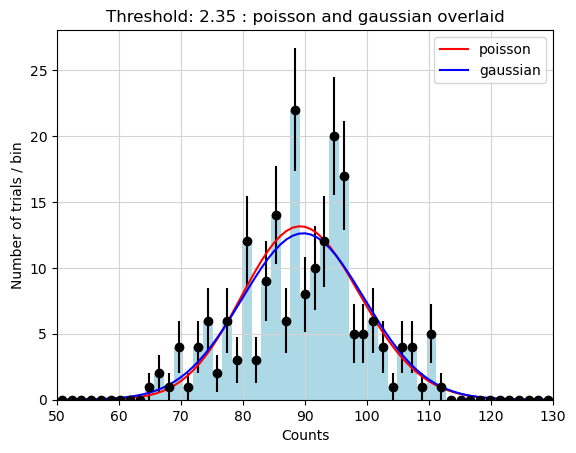

** Threshold: 2.35
 Fit to poisson PDF using poisson errors on bins
 chi^2 = 62.755766 / 29 DOF
 A = 312.724546 +/- 22.168455
 mean = 89.664510 +/- 0.671463
** Threshold: 2.35
 Fit to gaussian PDF using poisson errors on bins
 chi^2 = 60.572091 / 28 DOF
 A = 312.728869 +/- 22.168761
 mean = 89.663044 +/- 0.697749
 sigma = 9.838946 +/- 0.494907
** Threshold: 2.35
 Fit to poisson PDF using gaussian errors on bins
 chi^2 = 61.661920 / 29 DOF
 A = 361.174666 +/- 23.823908
 mean = 89.647297 +/- 0.563974
** Threshold: 2.35
 Fit to gaussian PDF using gaussian errors on bins
 chi^2 = 55.844816 / 28 DOF
 A = 356.630838 +/- 23.674465
 mean = 89.818091 +/- 0.687638
 sigma = 10.349878 +/- 0.494877
==*** end report for run 'Threshold: 2.35'



In [ ]:
proc_run('Threshold: 2.35',df_2_35 , 51,   50,   130)

**1. What do you notice about the distribution as the average number of counts per bin increases?**

As the average number of counts per bin increases, the distribution is smoother. 

\
**2. What do you notice about the fits?**

As the average number of counts per bin increases, the fits generally get better as there are more data points to base the fit off of. 

\
**3. Comment on the Gaussian fit to the run with the lowest number of counts per bin.**

The run that seems to have the lowest number of counts is the run with the threshold of 2.6. The reduced chi-squared value for the 
Gaussian fit to this run are not as good when compared to the fits on other runs. Notably, the data distribution does not appear to be 
symmetric here.

\
**4. In terms of statistical precision, does it matter whether you "count" for 10 bins of length T, and then add up all these counts, or just count for 1 bin of length 10T?**

No, it does not matter in terms of statistical precision; Counting 1 ten times is the same as counting 10 one time.

\
**5. Can you think of any reason why one of these two modes of counting may be preferred over the other?**

It would be better to count for 10 bins of length T when you want to monitor how something fluctuates over time (total counts don't matter, but how the collection of counts changes).
It would be better to count for 1 bin of length 10T when you only care about total counts and not when they come in. 